# Лабораторная работа 2 Исследовательский анализ данных

Дисциплина: «Анализ данных». Выполнил: Жойд Станислав Вадимович, группа 4417, вариант 8.

Преподаватель: Боженко Виктория Вячеславовна, старший преподаватель кафедры 41.

**Цель работы:** изучить связи между признаками набора кредитных заявок и выполнить визуализацию данных.

Набор `credit_risk.csv` содержит сведения о возрасте и доходе заявителя, жилье, стаже, цели и параметрах кредита, статусе одобрения, доле кредита в доходе, прежнем дефолте и продолжительности кредитной истории.

# 1 Загрузка и подготовка данных

Исходный набор загружается без изменения в `raw_df`. Для анализа создаётся копия `df`. Названия столбцов приводятся к нижнему регистру, исправляются два варианта написания категорий, удаляются точные повторы, строки с пропусками и предметно противоречивые наблюдения. Такой же подход применялся к этому файлу в первой лабораторной работе, поэтому результаты двух работ сопоставимы.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', font_scale=0.9)

figure_dir = Path('utility/figures')
figure_dir.mkdir(parents=True, exist_ok=True)
dataset_path = next((p for p in [Path('credit_risk.csv'), Path('utility/credit_risk.csv')] if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError('Файл credit_risk.csv не найден.')

raw_df = pd.read_csv(dataset_path)
df = raw_df.copy(deep=True)
print(f'Исходный набор: {df.shape[0]} строк, {df.shape[1]} столбцов')
display(df.head())

Исходный набор: 652 строк, 12 столбцов


,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,0,22.00,59000,RENT,123.00,PERSONAL,35000,16.02,1,0.59,Y,3
1,1,21.00,9600,OWN,5.00,EDUCATION,1000,11.14,0,0.10,N,2
2,2,25.00,9600,MORTGAGE,1.00,MEDICAL,5500,12.87,1,0.57,N,3
3,3,23.00,65500,RENT,4.00,MEDICAL,35000,15.23,1,0.53,N,2
4,4,24.00,54400,RENT,8.00,MEDICAL,35000,14.27,1,0.55,Y,4


## 1.1 Общая информация и описательная статистика

In [2]:
df.info()
display(df.describe().round(2))
display(df.isna().sum().rename('Количество пропусков').to_frame())
print(f'Полных повторов: {df.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              652 non-null    int64  
 1   Age             652 non-null    float64
 2   Income          652 non-null    int64  
 3   Home            652 non-null    str    
 4   Emp_length      643 non-null    float64
 5   Intent          652 non-null    str    
 6   Amount          652 non-null    int64  
 7   Rate            586 non-null    float64
 8   Status          652 non-null    int64  
 9   Percent_income  652 non-null    float64
 10  Default         652 non-null    str    
 11  Cred_length     652 non-null    int64  
dtypes: float64(4), int64(5), str(3)
memory usage: 61.3 KB


,Id,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length
count,652.00,652.00,652.00,643.00,652.00,586.00,652.00,652.00,652.00
mean,325.50,24.29,90008.86,4.60,18801.00,12.29,0.60,0.28,3.01
std,188.35,7.84,69530.31,7.28,9152.90,3.27,0.49,0.15,0.81
min,0.00,21.00,9600.00,0.00,1000.00,5.42,0.00,0.01,2.00
25%,162.75,23.00,44000.00,2.00,10000.00,10.25,0.00,0.16,2.00
50%,325.50,24.00,69998.00,4.00,21850.00,12.18,1.00,0.28,3.00
75%,488.25,25.00,128499.00,7.00,25000.00,14.72,1.00,0.38,4.00
max,649.00,144.00,500000.00,123.00,35000.00,21.21,1.00,0.83,4.00


,Количество пропусков
Id,0
Age,0
Income,0
Home,0
Emp_length,9
Intent,0
Amount,0
Rate,66
Status,0
Percent_income,0


Полных повторов: 2


В исходном файле 652 строки и 12 столбцов. В `Emp_length` отсутствуют 9 значений, в `Rate` — 66. Обнаружены две повторные копии строк. Возраст, стаж и процентная ставка требуют дополнительной проверки. Идентификатор `Id` не является количественной характеристикой заявителя и не участвует в визуальном анализе взаимосвязей.

## 1.2 Очистка данных

In [3]:
df.columns = df.columns.str.strip().str.lower()
df['home'] = df['home'].replace({'RENET': 'RENT'})
df['default'] = df['default'].replace({'No': 'N'})
before = len(df)
df = df.drop_duplicates().dropna().copy()
df = df.loc[(df['age'] <= 100) & (df['emp_length'] <= df['age'])].copy()
df['age'] = df['age'].astype('int64')
df['emp_length'] = df['emp_length'].astype('int64')
for column in ['home', 'intent', 'default', 'status']:
    df[column] = df[column].astype('category')
df = df.reset_index(drop=True)
df.to_csv('utility/credit_risk_clean.csv', index=False)
print(f'Удалено строк: {before - len(df)}')
print(f'Очищенный набор: {df.shape[0]} строк, {df.shape[1]} столбцов')
display(df.describe(include='all').transpose())

Удалено строк: 81
Очищенный набор: 571 строк, 12 столбцов


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,571.00,NaN,NaN,NaN,324.77,187.81,1.00,162.50,325.00,489.50,649.00
age,571.00,NaN,NaN,NaN,23.79,1.48,21.00,23.00,24.00,25.00,26.00
income,571.00,NaN,NaN,NaN,91102.01,69188.41,9600.00,46750.00,70000.00,130000.00,500000.00
home,571,4,RENT,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emp_length,571.00,NaN,NaN,NaN,4.26,3.05,0.00,2.00,4.00,7.00,11.00
intent,571,6,EDUCATION,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,571.00,NaN,NaN,NaN,19168.26,8936.22,1000.00,12000.00,22000.00,25000.00,35000.00
rate,571.00,NaN,NaN,NaN,12.35,3.25,5.79,10.36,12.18,14.74,21.21
status,571.00,2.00,1.00,342.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
percent_income,571.00,NaN,NaN,NaN,0.28,0.15,0.01,0.16,0.28,0.38,0.83


После очистки осталось 571 наблюдение. Удалены 81 строка: две повторные копии, строки с пропусками и записи с возрастом выше 100 лет либо стажем больше возраста. Доход 500 000 сохранён, поскольку необычное значение без дополнительного подтверждения нельзя считать ошибкой.

# 2 Диаграммы рассеяния

Матрица рассеяния строится для семи содержательных числовых признаков. Категориальное сравнение выполнено отдельно: зависимость дохода и суммы кредита показана по целям кредита разными цветами.

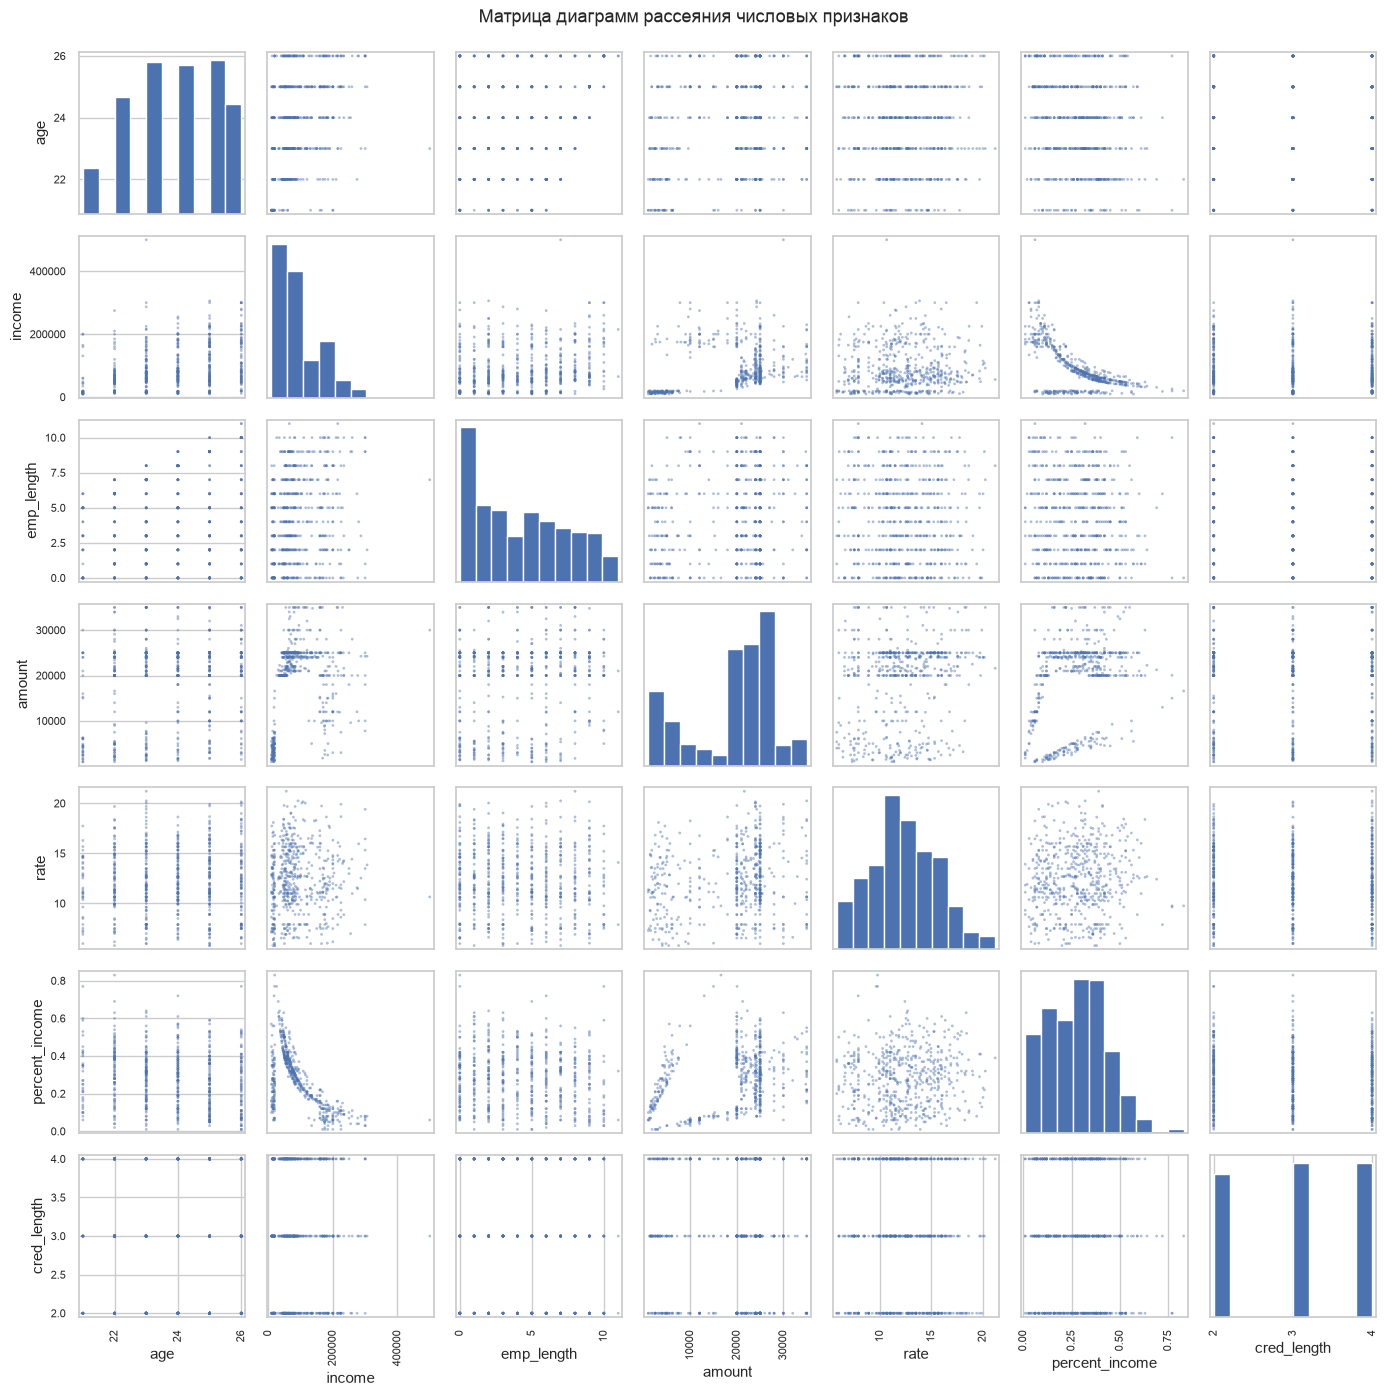

In [4]:
numeric = ['age', 'income', 'emp_length', 'amount', 'rate', 'percent_income', 'cred_length']
axes = pd.plotting.scatter_matrix(df[numeric], figsize=(14, 14), diagonal='hist', alpha=0.45, s=16)
plt.suptitle('Матрица диаграмм рассеяния числовых признаков', y=0.995)
plt.tight_layout()
plt.savefig(figure_dir / '01_scatter_matrix.png', dpi=220, bbox_inches='tight')
plt.show()

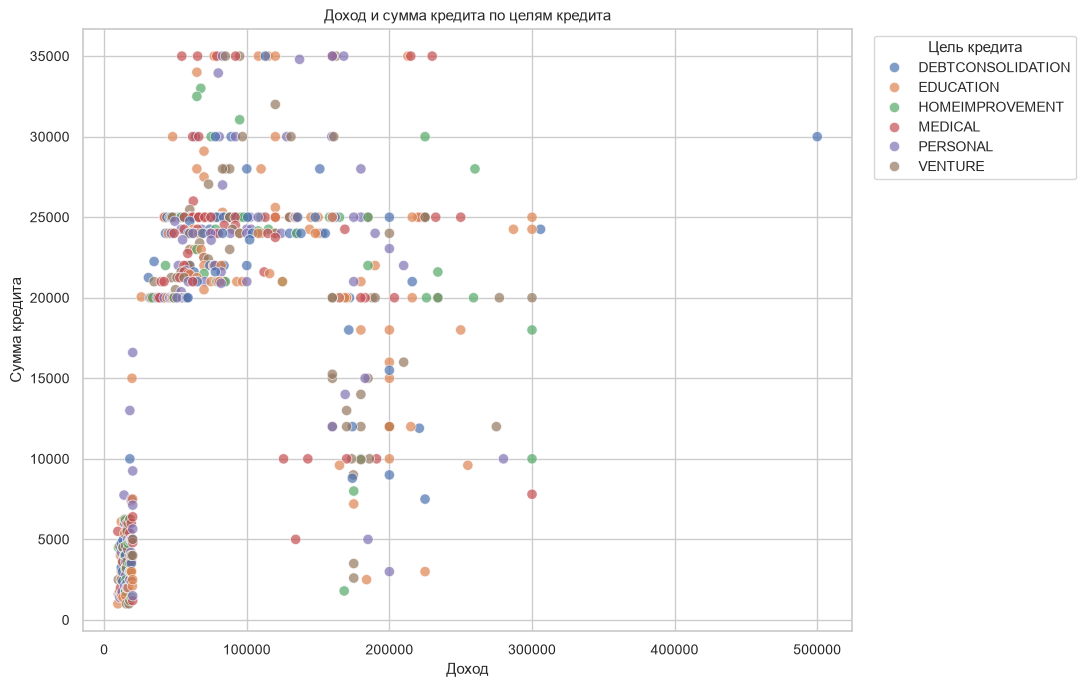

In [5]:
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df, x='income', y='amount', hue='intent', alpha=0.7, s=55)
plt.title('Доход и сумма кредита по целям кредита')
plt.xlabel('Доход')
plt.ylabel('Сумма кредита')
plt.legend(title='Цель кредита', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(figure_dir / '02_scatter_by_intent.png', dpi=220, bbox_inches='tight')
plt.show()

Матрица не показывает единственной сильной линейной зависимости для всех пар. Более заметны рост дохода с возрастом, рост суммы кредита с доходом и обратная связь дохода с долей кредита в доходе. На категориальной диаграмме цели кредита значительно перекрываются: одна только пара `income` и `amount` не разделяет заявки по целям.

# 3 Гистограммы числовых признаков

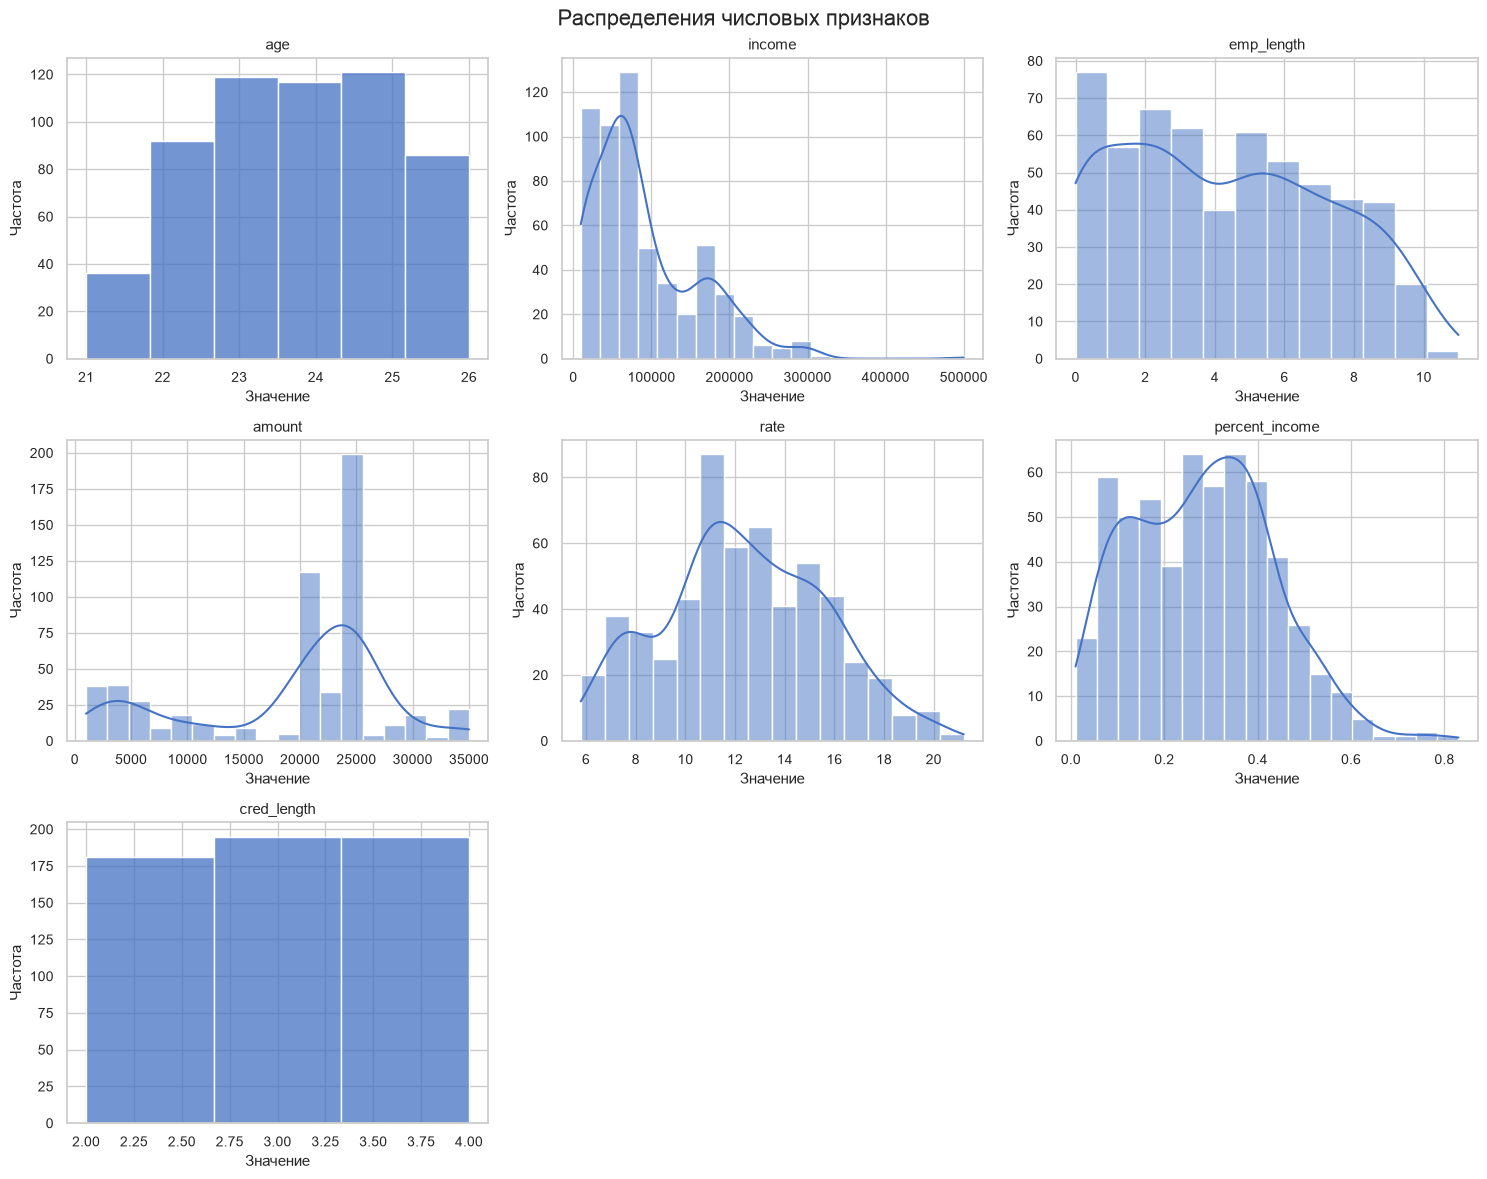

In [6]:
bins = {'age': 6, 'income': 20, 'emp_length': 12, 'amount': 18, 'rate': 16, 'percent_income': 18, 'cred_length': 3}
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, column in zip(axes.flat, numeric):
    sns.histplot(df[column], bins=bins[column], kde=column not in ['age', 'cred_length'], ax=ax, color='#4472C4')
    ax.set_title(column)
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')
for ax in axes.flat[len(numeric):]:
    ax.axis('off')
fig.suptitle('Распределения числовых признаков', fontsize=16)
fig.tight_layout()
fig.savefig(figure_dir / '03_histograms.png', dpi=220, bbox_inches='tight')
plt.show()

Возраст сосредоточен в диапазоне 21–26 лет. Доход имеет выраженный правый хвост: большинство значений значительно ниже максимума 500 000. Сумма кредита имеет дискретное многовершинное распределение с крупной группой около 20 000–25 000 и отдельной группой небольших сумм. Ставки распределены шире вокруг 10–15 %. Доля кредита в доходе чаще находится примерно между 0,15 и 0,40. Стаж сконцентрирован в первых нескольких годах, а кредитная история принимает только значения от 2 до 4 лет. Количество интервалов выбрано с учётом дискретности и объёма выборки, чтобы не скрывать форму распределения и не создавать излишний шум.

# 4 Корреляция и ковариация

,age,income,emp_length,amount,rate,percent_income,cred_length
age,1.00,0.34,0.21,0.19,0.03,-0.17,-0.00
income,0.34,1.00,0.19,0.28,0.05,-0.64,0.01
emp_length,0.21,0.19,1.00,0.14,-0.04,-0.09,-0.08
amount,0.19,0.28,0.14,1.00,0.20,0.32,-0.01
rate,0.03,0.05,-0.04,0.20,1.00,0.06,-0.05
percent_income,-0.17,-0.64,-0.09,0.32,0.06,1.00,-0.03
cred_length,-0.00,0.01,-0.08,-0.01,-0.05,-0.03,1.00


,age,income,emp_length,amount,rate,percent_income,cred_length
age,2.20,34394.51,0.93,2567.03,0.12,-0.04,-0.00
income,34394.51,4787035961.85,40703.79,175207803.82,10240.90,-6603.53,381.78
emp_length,0.93,40703.79,9.28,3890.14,-0.39,-0.04,-0.20
amount,2567.03,175207803.82,3890.14,79856046.56,5741.28,434.29,-35.23
rate,0.12,10240.90,-0.39,5741.28,10.58,0.03,-0.13
percent_income,-0.04,-6603.53,-0.04,434.29,0.03,0.02,-0.00
cred_length,-0.00,381.78,-0.20,-35.23,-0.13,-0.00,0.66


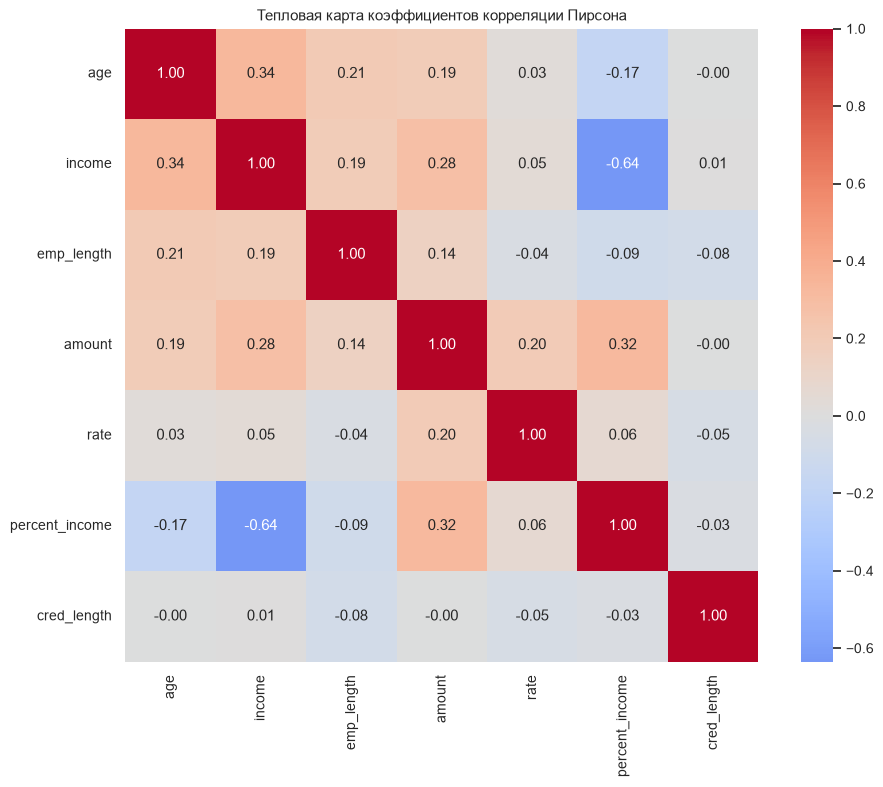

In [7]:
correlation = df[numeric].corr(method='pearson')
covariance = df[numeric].cov()
display(correlation.round(3))
display(covariance.round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Тепловая карта коэффициентов корреляции Пирсона')
plt.tight_layout()
plt.savefig(figure_dir / '04_correlation_heatmap.png', dpi=220, bbox_inches='tight')
plt.show()

Наиболее выраженная связь — отрицательная корреляция дохода и доли кредита в доходе, равная примерно −0,64. Умеренная положительная связь наблюдается между суммой кредита и долей кредита в доходе, около 0,32, а также между возрастом и доходом, около 0,34. Связь дохода и суммы кредита слабее, около 0,28. Остальные коэффициенты близки к нулю или малы. Ковариация имеет знак, совпадающий с направлением связи, но её величина зависит от единиц измерения, поэтому для сопоставления силы связей удобнее корреляция. Корреляция не доказывает причинность.

# 5 Графики варианта 8

## 5.1 Количество заявок по цели кредита и статусу домовладения

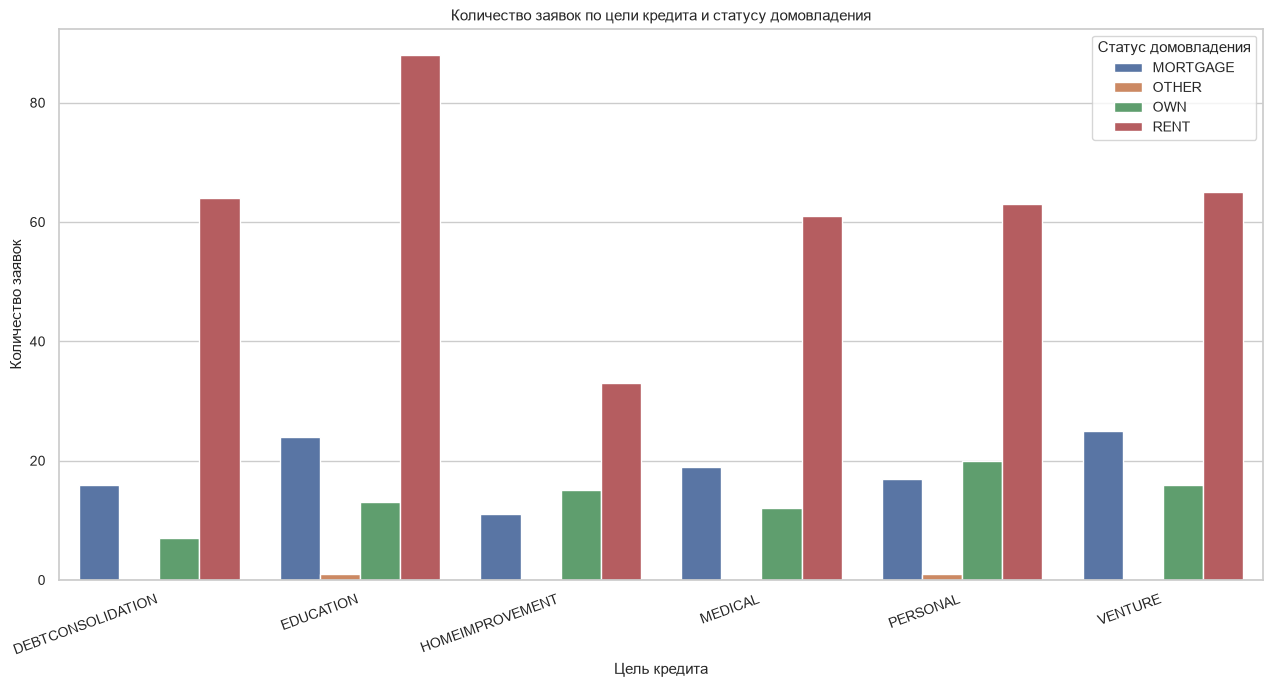

home,MORTGAGE,OTHER,OWN,RENT
intent,,,,
DEBTCONSOLIDATION,16,0,7,64
EDUCATION,24,1,13,88
HOMEIMPROVEMENT,11,0,15,33
MEDICAL,19,0,12,61
PERSONAL,17,1,20,63
VENTURE,25,0,16,65


In [8]:
intent_home = df.groupby(['intent', 'home'], observed=True).size().reset_index(name='count')
plt.figure(figsize=(13, 7))
sns.barplot(data=intent_home, x='intent', y='count', hue='home')
plt.title('Количество заявок по цели кредита и статусу домовладения')
plt.xlabel('Цель кредита')
plt.ylabel('Количество заявок')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Статус домовладения')
plt.tight_layout()
plt.savefig(figure_dir / '05_variant_intent_home.png', dpi=220, bbox_inches='tight')
plt.show()
display(intent_home.pivot(index='intent', columns='home', values='count').fillna(0).astype(int))

Во всех целях кредита преобладают арендаторы. Наибольшее число заявок арендаторов связано с образованием — 88. Наименьшее общее число заявок относится к улучшению жилья. Категория `OTHER` содержит только две записи, поэтому выводы по ней неустойчивы.

## 5.2 Средний доход по возрасту

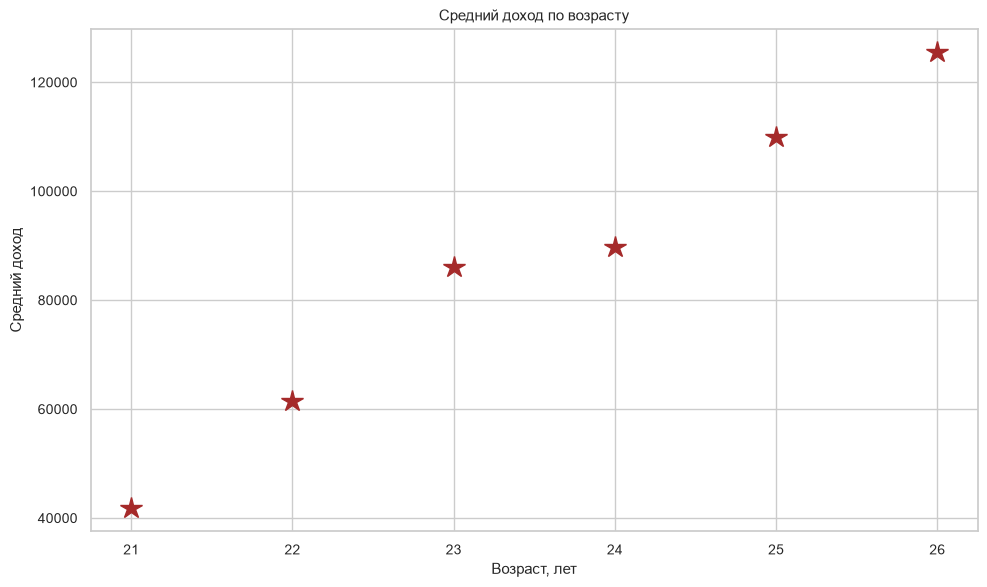

,income
age,
21,41783.50
22,61425.70
23,86162.54
24,89681.13
25,110021.18
26,125642.78


In [9]:
mean_income_by_age = df.loc[df['age'] < 100].pivot_table(index='age', values='income', aggfunc='mean', observed=True).round(2)
ax = mean_income_by_age.plot(style='*', color='brown', markersize=16, linestyle='None', figsize=(10, 6), legend=False)
ax.set_title('Средний доход по возрасту')
ax.set_xlabel('Возраст, лет')
ax.set_ylabel('Средний доход')
plt.tight_layout()
plt.savefig(figure_dir / '06_variant_income_age.png', dpi=220, bbox_inches='tight')
plt.show()
display(mean_income_by_age)

Средний доход последовательно увеличивается от 41 783,50 в возрасте 21 года до 125 642,78 в возрасте 26 лет. Это поперечное сравнение разных заявителей, а не наблюдение роста дохода одного человека, поэтому причинный вывод делать нельзя.

## 5.3 Доли целей кредита

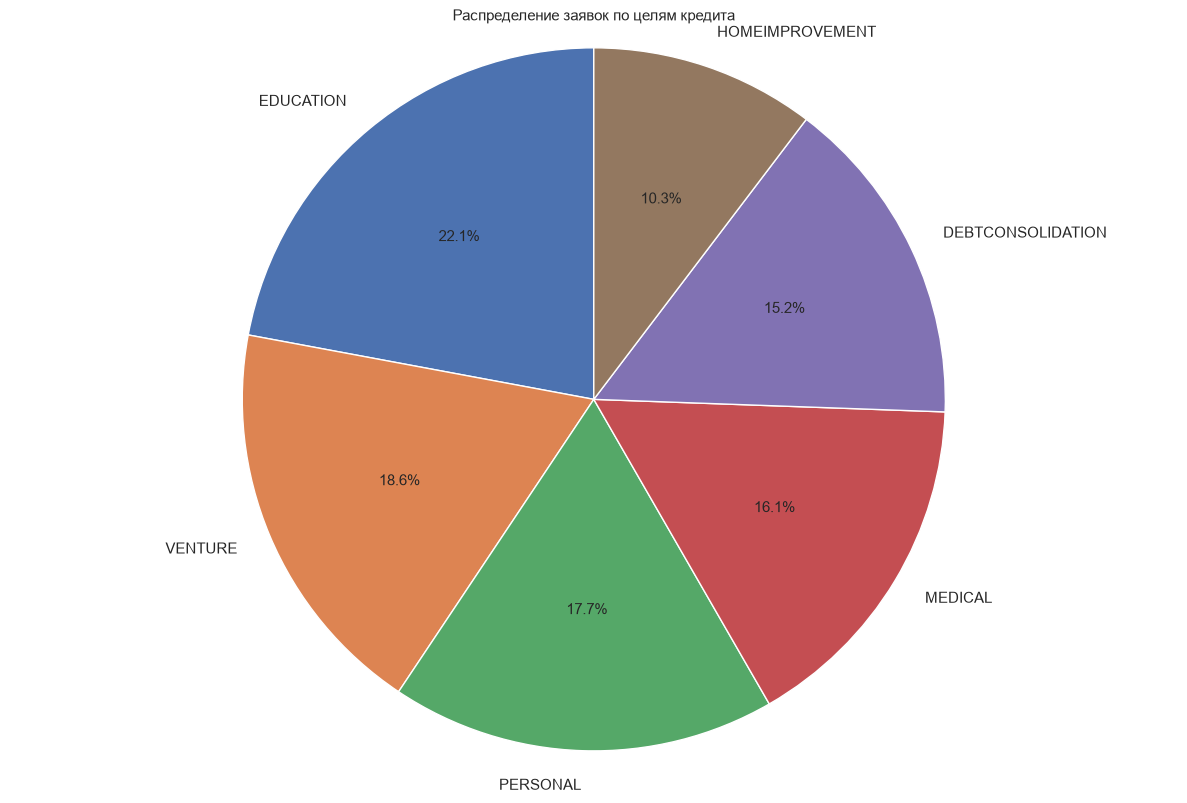

,count
intent,
EDUCATION,126
VENTURE,106
PERSONAL,101
MEDICAL,92
DEBTCONSOLIDATION,87
HOMEIMPROVEMENT,59


In [10]:
intent_counts = df['intent'].value_counts()
fig, ax = plt.subplots(figsize=(12, 8))
ax.pie(intent_counts.values, labels=intent_counts.index, autopct='%1.1f%%', startangle=90, textprops={'size': 11})
ax.set_title('Распределение заявок по целям кредита')
ax.axis('equal')
fig.tight_layout()
fig.savefig(figure_dir / '07_variant_intent_pie.png', dpi=220, bbox_inches='tight')
plt.show()
display(intent_counts.rename('count').to_frame())

Наиболее распространённая цель — образование: 126 заявок, или около 22,1 %. Далее следуют предпринимательство и личные нужды. Реже всего встречается улучшение жилья — 59 заявок, около 10,3 %.

# 6 Hexagonal binning plot

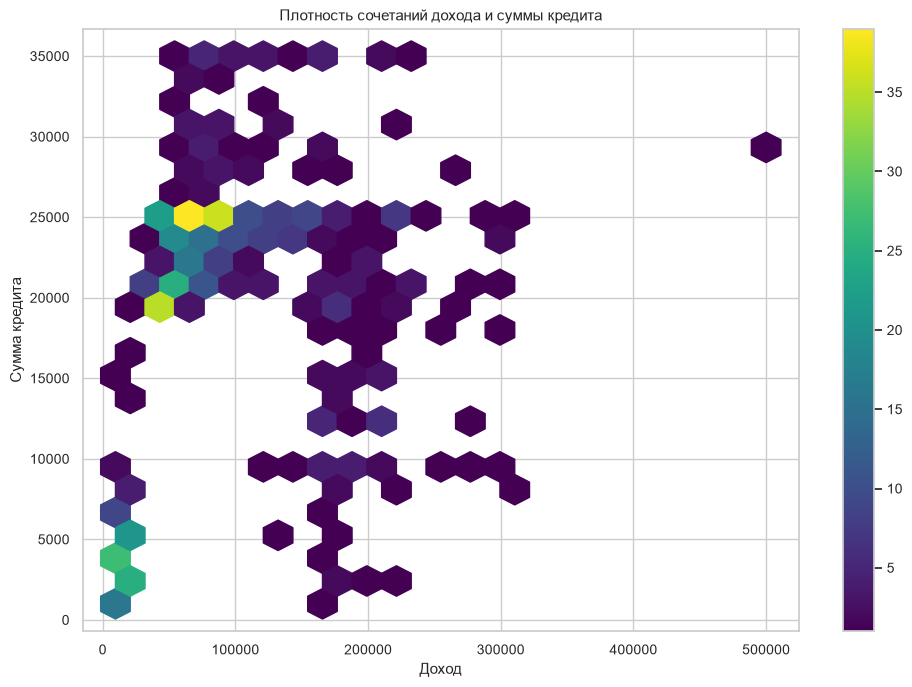

In [11]:
ax = df.plot.hexbin(x='income', y='amount', gridsize=22, figsize=(10, 7), cmap='viridis', mincnt=1, sharex=False)
ax.set_title('Плотность сочетаний дохода и суммы кредита')
ax.set_xlabel('Доход')
ax.set_ylabel('Сумма кредита')
plt.tight_layout()
plt.savefig(figure_dir / '08_hexbin_income_amount.png', dpi=220, bbox_inches='tight')
plt.show()

Наибольшая плотность наблюдений находится в области относительно невысоких и средних доходов и сумм кредита. При больших доходах точки редки. Наклон плотной области вверх согласуется со слабой положительной корреляцией дохода и суммы кредита, но разброс остаётся значительным.

# 7 Диаграммы размаха

## 7.1 Сумма кредита

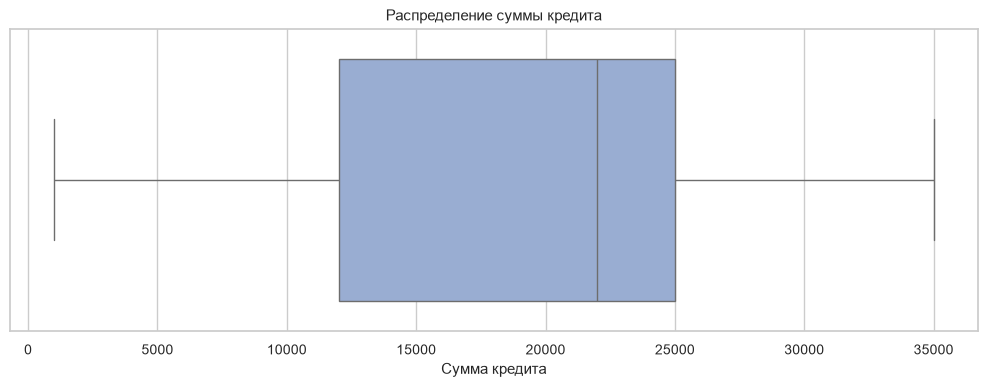

In [12]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['amount'], color='#8FAADC')
plt.title('Распределение суммы кредита')
plt.xlabel('Сумма кредита')
plt.tight_layout()
plt.savefig(figure_dir / '09_box_amount.png', dpi=220, bbox_inches='tight')
plt.show()

Медиана суммы кредита равна 22 000, первый квартиль — 12 000, третий — 25 000. Усы охватывают диапазон от 1 000 до 35 000; отдельных выбросов по правилу 1,5 межквартильного размаха на общей диаграмме нет.

## 7.2 Доход по новой категории дохода

,count,min,median,max
income_level,,,,
Низкий,195,9600,20000.00,54000
Средний,187,54400,70550.00,95000
Высокий,189,96000,170000.00,500000


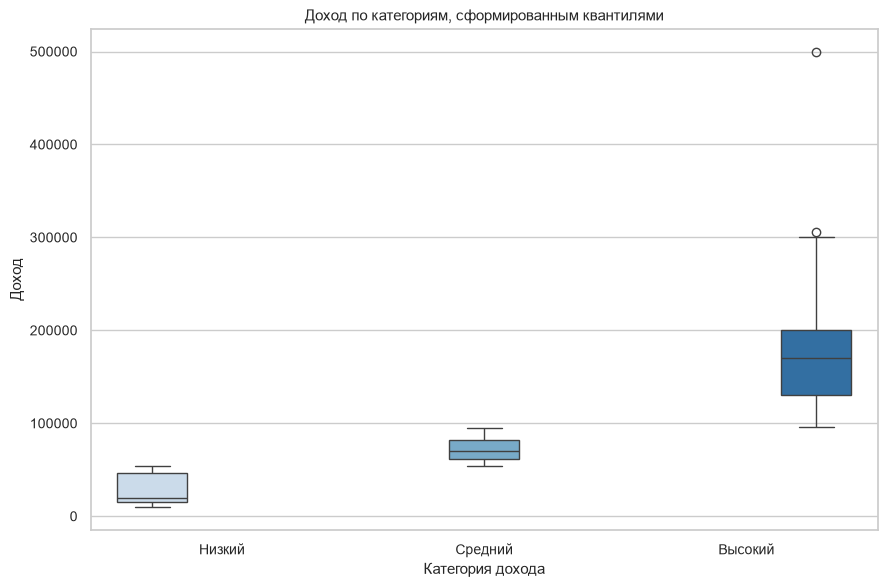

In [13]:
df['income_level'] = pd.qcut(df['income'], q=3, labels=['Низкий', 'Средний', 'Высокий'])
display(df.groupby('income_level', observed=True)['income'].agg(['count', 'min', 'median', 'max']).round(2))
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='income_level', y='income', hue='income_level', palette='Blues', legend=False)
plt.title('Доход по категориям, сформированным квантилями')
plt.xlabel('Категория дохода')
plt.ylabel('Доход')
plt.tight_layout()
plt.savefig(figure_dir / '10_box_income_level.png', dpi=220, bbox_inches='tight')
plt.show()

Функция `qcut` разделила наблюдения на три близкие по размеру группы: 195, 187 и 189 записей. Границы определены распределением данных, а не произвольными фиксированными числами. В высокой категории заметен длинный правый хвост до 500 000.

## 7.3 Сумма кредита по цели

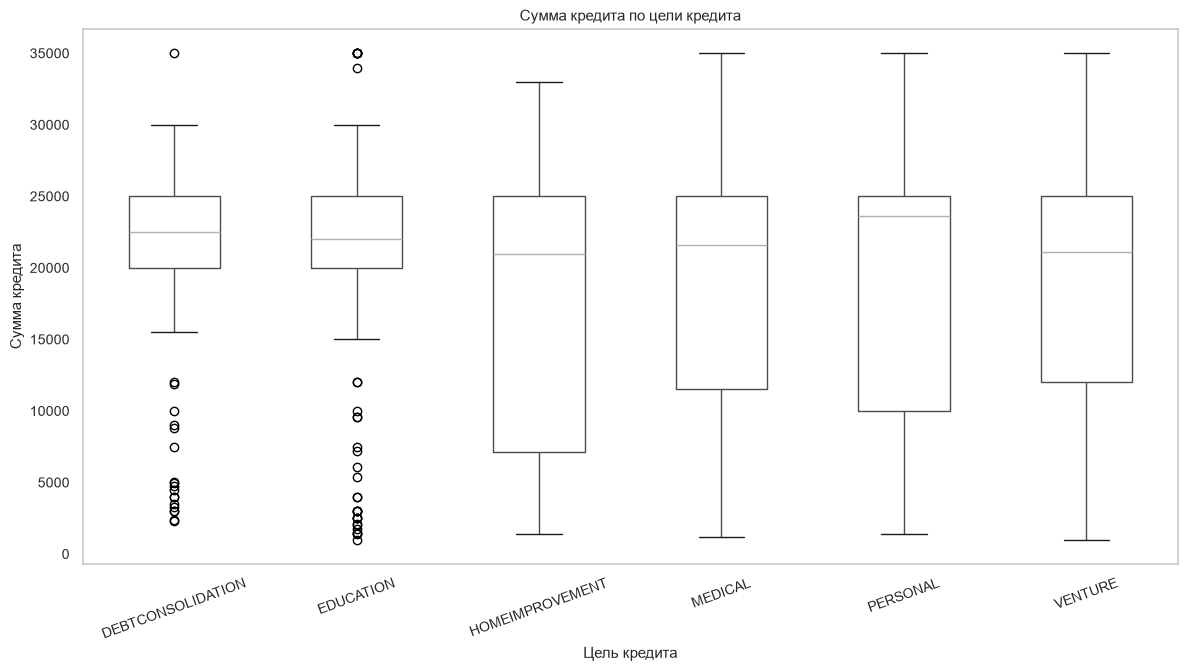

In [14]:
ax = df.boxplot(column='amount', by='intent', figsize=(12, 7), grid=False, rot=20)
plt.suptitle('')
ax.set_title('Сумма кредита по цели кредита')
ax.set_xlabel('Цель кредита')
ax.set_ylabel('Сумма кредита')
plt.tight_layout()
plt.savefig(figure_dir / '11_box_amount_intent.png', dpi=220, bbox_inches='tight')
plt.show()

Медианы сумм по целям близки, а распределения сильно перекрываются. Во всех категориях присутствуют крупные заявки, поэтому цель кредита сама по себе слабо разделяет сумму.

## 7.4 Доход по статусу домовладения

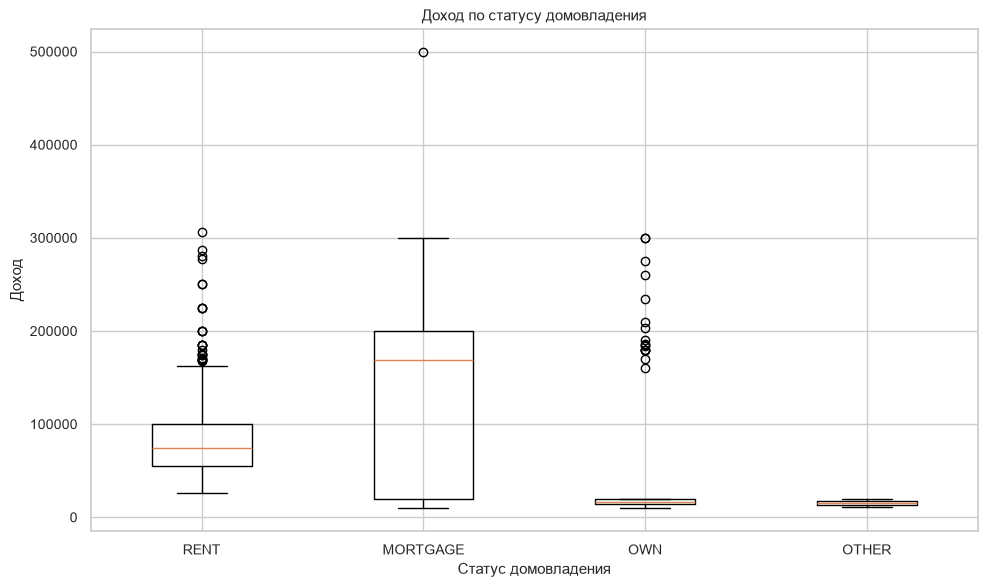

In [15]:
home_order = ['RENT', 'MORTGAGE', 'OWN', 'OTHER']
groups = [df.loc[df['home'] == category, 'income'] for category in home_order]
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(groups, tick_labels=home_order, showfliers=True)
ax.set_title('Доход по статусу домовладения')
ax.set_xlabel('Статус домовладения')
ax.set_ylabel('Доход')
fig.tight_layout()
fig.savefig(figure_dir / '12_box_income_home.png', dpi=220, bbox_inches='tight')
plt.show()

Распределения дохода по статусам домовладения перекрываются и имеют правые хвосты. Категория `OTHER` представлена всего двумя наблюдениями, поэтому её ящик нельзя надёжно сравнивать с остальными. В работе использованы seaborn, pandas plotting и matplotlib, что выполняет требование о разных библиотеках.

# Заключение

В ходе работы выполнен исследовательский анализ набора кредитных заявок `credit_risk.csv`. Исходные 652 строки были проверены на пропуски, повторы, ошибки написания категорий и предметные аномалии. После удаления неполных, повторных и противоречивых записей сформирована выборка из 571 наблюдения.

Распределение дохода асимметрично вправо, сумма кредита образует несколько выраженных групп, а возраст заявителей сосредоточен между 21 и 26 годами. Наиболее заметна отрицательная корреляция дохода с долей кредита в доходе, около −0,64. Связи возраста с доходом, суммы кредита с доходом и суммы кредита с её долей в доходе положительны, но не являются сильными. Графики не дают основания утверждать причинную зависимость.

В варианте 8 установлено преобладание арендаторов во всех целях кредита, рост среднего дохода по возрастным группам и наибольшая доля заявок на образование. Hexbin и диаграммы размаха подтвердили концентрацию наблюдений в области умеренных значений и наличие правых хвостов. Результаты описывают очищенную подвыборку и должны интерпретироваться с учётом удаления строк с пропусками и малых категорий.